In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Marketing AB Testing/marketing_AB.csv') # Replace 'your_dataset.csv' with your actual file path
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null  object
 6   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(4), object(2)
memory usage: 27.5+ MB


Dropping 'Unnamed: 0', since it is just row index

In [ ]:
df = df.drop(labels = 'Unnamed: 0', axis = 1)

In [ ]:
df.shape

(588101, 6)

Renaming few columns

In [ ]:
df_filtered = df_filtered.rename(columns={'user id': 'user_id',
                                          'test group': 'test_grp',
                                          'total ads': 'total_ads_shown',
                                          'most ads day': 'most_ads_day',
                                          'most ads hour': 'most_ads_hour'})

print("Columns after renaming:")
print(df_filtered.columns)

Columns after renaming:
Index(['user_id', 'test_grp', 'converted', 'total_ads_shown', 'most_ads_day',
       'most_ads_hour'],
      dtype='object')


In [ ]:
df_filtered['converted_int'] = df_filtered['converted'].astype(int)

print("First 5 rows with new 'converted_int' column:")
display(df_filtered.head())

First 5 rows with new 'converted_int' column:


,user_id,test_grp,converted,total_ads_shown,most_ads_day,most_ads_hour,converted_int
0,1069124,ad,False,130,Monday,20,0
1,1119715,ad,False,93,Tuesday,22,0
2,1144181,ad,False,21,Tuesday,18,0
7,1496843,ad,False,17,Sunday,18,0
8,1448851,ad,False,21,Tuesday,19,0


Now, let's perform some additional data validation by checking the unique values for categorical columns like 'most ads day' and 'most ads hour', and confirm their data types.

In [ ]:
print("Unique values for 'most ads day':")
print(df_filtered['most_ads_day'].unique())

print("\nUnique values for 'most ads hour':")
print(df_filtered['most_ads_hour'].unique())

print("\nData types of relevant columns:")
print(df_filtered[['most_ads_day', 'most_ads_hour', 'converted', 'converted_int']].dtypes)

Unique values for 'most ads day':
['Monday' 'Tuesday' 'Sunday' 'Wednesday' 'Friday' 'Saturday' 'Thursday']

Unique values for 'most ads hour':
[20 22 18 19 14 13 12 11 16 21 23  4  8 10  0 15  1  2  6  3 17  9  7  5]

Data types of relevant columns:
most_ads_day     object
most_ads_hour     int64
converted          bool
converted_int     int64
dtype: object


finding duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(0)

finding null values

In [ ]:
df.isnull().sum()

,0
user id,0
test group,0
converted,0
total ads,0
most ads day,0
most ads hour,0


defining a general outlier detection function

In [ ]:
def detect_outliers(df, col):
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  return outliers[col]

Checking if there are any outliers present for 'total ads'

In [ ]:
detect_outliers(df, 'total ads').reset_index(drop=True)

,total ads
0,130
1,93
2,355
3,276
4,734
...,...
52052,70
52053,65
52054,70
52055,64


In [ ]:
df['total ads'].skew()

np.float64(7.433113001521166)

The data is heavily right skewed

Viewing with the help of box plot

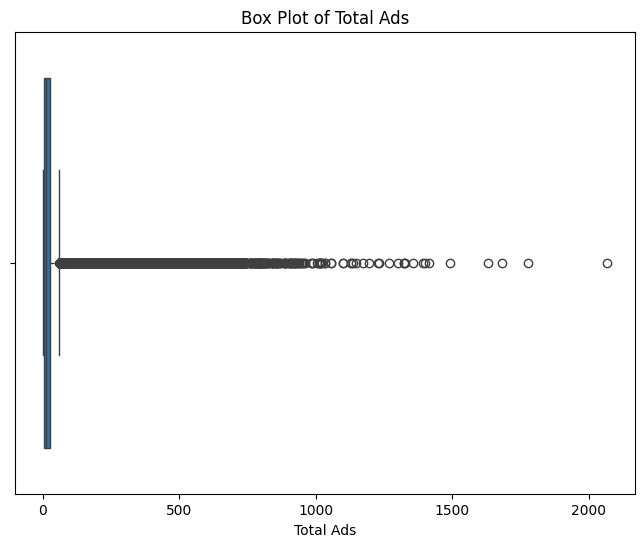

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['total ads'])
plt.title('Box Plot of Total Ads')
plt.xlabel('Total Ads')
plt.show()

We want to find the number of rows having total ads > 200, if the percentage < 2% we can remove those rows to reduce target bias and analyse more effectively

In [ ]:
num_rows_greater_than_200 = (df['total ads'] > 200).sum()
total_rows = df.shape[0]
percentage = (num_rows_greater_than_200 / total_rows) * 100
print(f"Percentage of rows with 'total ads' > 200: {percentage:.2f}%")

Percentage of rows with 'total ads' > 200: 1.01%


since the pct = 1% we can remove these values

Original DataFrame shape: (588101, 6)
Filtered DataFrame shape (after removing 'total ads' > 200): (582149, 6)


,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
7,1496843,ad,False,17,Sunday,18
8,1448851,ad,False,21,Tuesday,19


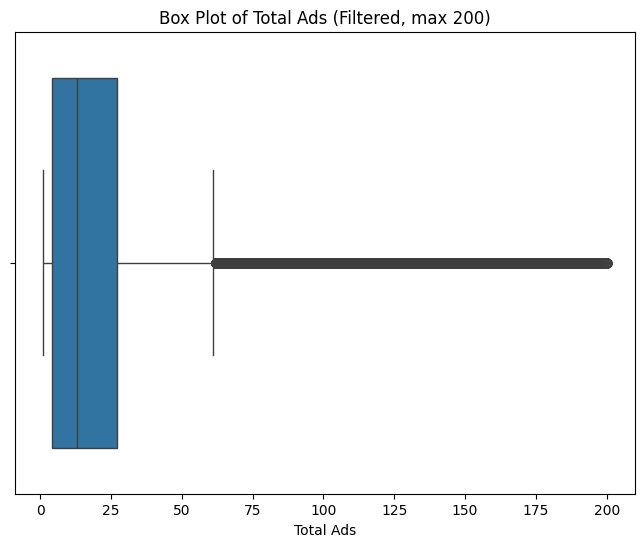

In [ ]:
df_filtered = df[df['total ads'] <= 200]

print(f"Original DataFrame shape: {df.shape}")
print(f"Filtered DataFrame shape (after removing 'total ads' > 200): {df_filtered.shape}")

display(df_filtered.head())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x=df_filtered['total ads'])
plt.title('Box Plot of Total Ads (Filtered, max 200)')
plt.xlabel('Total Ads')
plt.show()

We don't need to check for most ads hour since its hour of day that the person saw the biggest amount of ads.

Full data inventory & group validation

In [ ]:
group_distribution = df_filtered['test group'].value_counts()
total_entries = df_filtered.shape[0]

print("Test Group Distribution:")
print(group_distribution)
print("\nTest Group Percentage Distribution:")
print((group_distribution / total_entries) * 100)

Test Group Distribution:
test group
ad     558883
psa     23266
Name: count, dtype: int64

Test Group Percentage Distribution:
test group
ad     96.003429
psa     3.996571
Name: count, dtype: float64


In [ ]:
conversion_rates = df_filtered.groupby('test group')['converted'].mean() * 100
print("Conversion Rates by Test Group:")
print(conversion_rates)

Conversion Rates by Test Group:
test group
ad     2.421974
psa    1.633285
Name: converted, dtype: float64


The conversion rates show the percentage of users in each group who performed the desired action (converted). We can see the conversion rate for the 'ad' group and the 'psa' group.

Feature Engineering

In [ ]:
# Create ads_bucket feature
bins_ads = [0, 20, 50, 100, 201] # 201 to include 200
labels_ads = ['Very low', 'Low', 'Medium', 'High']
df_filtered['ads_bucket'] = pd.cut(df_filtered['total_ads_shown'], bins=bins_ads, labels=labels_ads, right=False, include_lowest=True)

# Create is_weekend feature
weekend_days = ['Saturday', 'Sunday']
df_filtered['is_weekend'] = df_filtered['most_ads_day'].isin(weekend_days)

# Create hour_period feature
bins_hour = [-1, 5, 11, 17, 23] # -1 to include 0, 23 to include 23
labels_hour = ['Night', 'Morning', 'Afternoon', 'Evening']
df_filtered['hour_period'] = pd.cut(df_filtered['most_ads_hour'], bins=bins_hour, labels=labels_hour, right=True)

print("First 5 rows with new features:")
display(df_filtered[['total_ads_shown', 'ads_bucket', 'most_ads_day', 'is_weekend', 'most_ads_hour', 'hour_period']].head())

First 5 rows with new features:


,total_ads_shown,ads_bucket,most_ads_day,is_weekend,most_ads_hour,hour_period
0,130,High,Monday,False,20,Evening
1,93,Medium,Tuesday,False,22,Evening
2,21,Low,Tuesday,False,18,Evening
7,17,Very low,Sunday,True,18,Evening
8,21,Low,Tuesday,False,19,Evening


Importing to cleaned csv

In [ ]:
df_filtered.to_csv('df_cleaned_final.csv', index=False)
print("Filtered DataFrame saved to 'df_cleaned_final.csv'")

Filtered DataFrame saved to 'df_cleaned_final.csv'
